In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("final_cleaned_data.csv")
df.columns

Index(['company_names', 'cars_names', 'engines', 'cc_battery_capacity',
       'horsepower', 'total_speed', 'cars_prices', 'fuel_types', 'seats',
       'torque', 'engine_cc', 'battery_kwh', 'has_battery', 'has_engine',
       'vehicle_type', 'acceleration_0_100'],
      dtype='object')

In [2]:
print("Mean:", df["cars_prices"].mean())
print("Median:", df["cars_prices"].median())
print("Minimum:", df["cars_prices"].min())
print("Maximum:", df["cars_prices"].max())

Mean: 138399.7291838417
Median: 42500.0
Minimum: 4000.0
Maximum: 18000000.0


In [3]:
price_thresholds = [50000, 100000, 150000, 250000, 500000]

for threshold in price_thresholds:
    count = (df["cars_prices"] > threshold).sum()
    percentage = count / len(df) * 100
    
    print(
        f"Above ${threshold:,}: "
        f"{count} cars ({percentage:.2f}%)"
    )


Above $50,000: 482 cars (39.74%)
Above $100,000: 201 cars (16.57%)
Above $150,000: 135 cars (11.13%)
Above $250,000: 85 cars (7.01%)
Above $500,000: 30 cars (2.47%)


In [4]:
df.nlargest(
    30,
    "cars_prices"
)[[
    "company_names",
    "cars_names",
    "cars_prices",
    "horsepower",
    "total_speed",
    "torque",
    "fuel_types"
]]

,company_names,cars_names,cars_prices,horsepower,total_speed,torque,fuel_types
883,Bugatti,La Voiture Noire,18000000.0,1500.0,420.0,1600.0,Petrol
882,Bugatti,Centodieci,9000000.0,1600.0,380.0,1600.0,Petrol
1207,Mazda,787B (Race Car),6000000.0,700.0,320.0,500.0,Petrol
881,Bugatti,Divo,5800000.0,1500.0,380.0,1600.0,Petrol
885,Bugatti,Mistral,5000000.0,1600.0,420.0,1600.0,Petrol
8,LAMBORGHINI,VENENO ROADSTER,4500000.0,750.0,356.0,690.0,Petrol
884,Bugatti,Bolide,4500000.0,1850.0,500.0,1600.0,Petrol
878,Bugatti,Chiron Super Sport,3500000.0,1600.0,490.0,1600.0,Petrol
877,Bugatti,Chiron Pur Sport,3300000.0,1500.0,350.0,1600.0,Petrol
879,Bugatti,Chiron Sport,3300000.0,1500.0,420.0,1600.0,Petrol


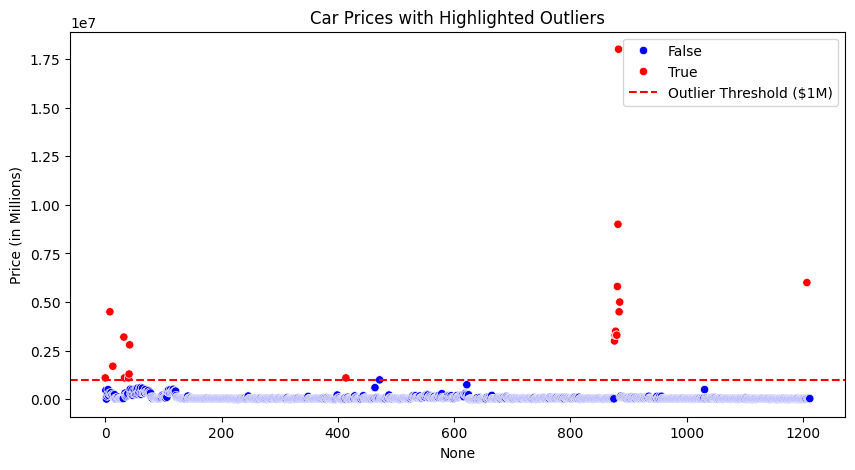

In [5]:

# Create a coloring rule based on your outlier threshold
df['is_outlier'] = df['cars_prices'] > 1000000

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x=df.index, y='cars_prices', hue='is_outlier', palette={False: 'blue', True: 'red'})

# Draw a distinct threshold line at 1 million
plt.axhline(y=1000000, color='red', linestyle='--', label='Outlier Threshold ($1M)')

plt.title('Car Prices with Highlighted Outliers')
plt.ylabel('Price (in Millions)')
plt.legend()
plt.show()


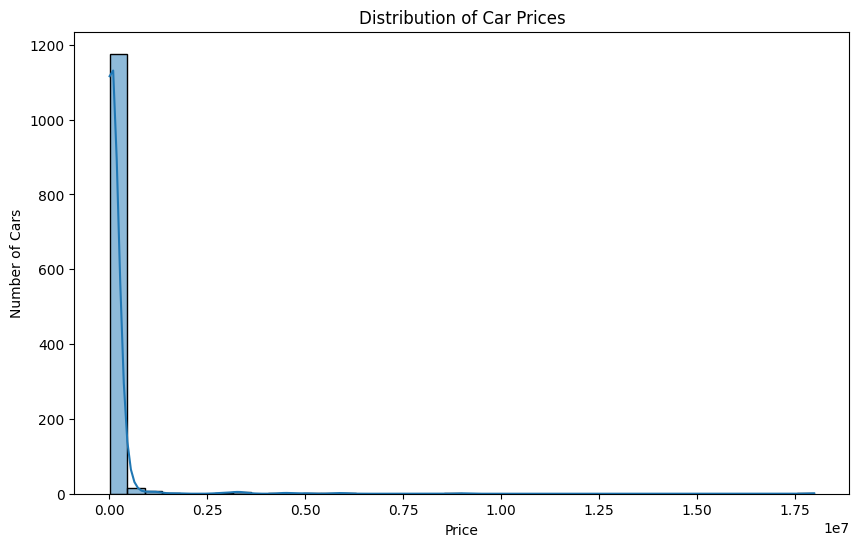

In [6]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["cars_prices"],
    bins=40,
    kde=True
)

plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Prices")

plt.show()

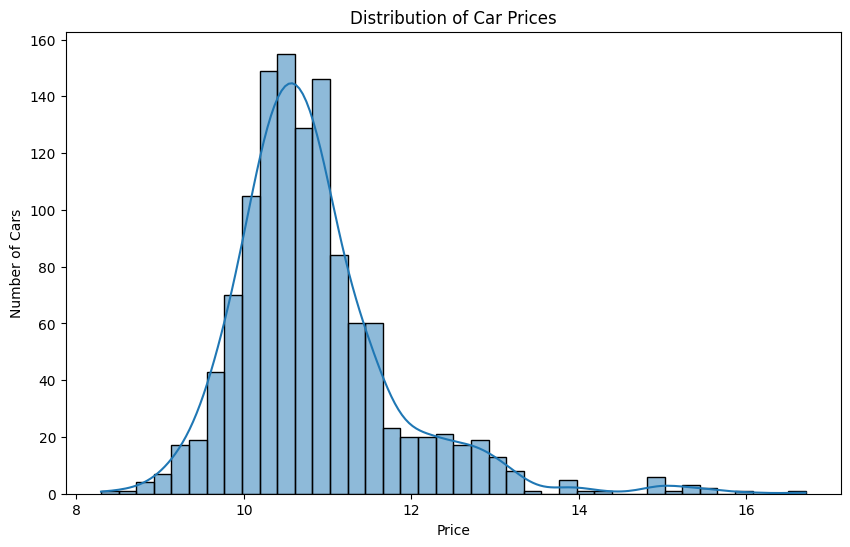

In [7]:
import numpy as np
df["log_price"] = np.log1p(df["cars_prices"])
plt.figure(figsize=(10, 6))

sns.histplot(
    df["log_price"],
    bins=40,
    kde=True
)

plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Prices")

plt.show()


In [8]:
df["price_segment"] = pd.cut(
    df["cars_prices"],
    bins=[
        0,
        50000,
        100000,
        250000,
        np.inf
    ],
    labels=[
        "Budget",
        "Mid-range",
        "Luxury",
        "Ultra-luxury"
    ]
)
df["price_segment"].value_counts()

price_segment
Budget          731
Mid-range       281
Luxury          116
Ultra-luxury     85
Name: count, dtype: int64

In [9]:
df.groupby("price_segment", observed=True)[
    ["horsepower", "total_speed", "torque"]
].mean().round(2)

,horsepower,total_speed,torque
price_segment,,,
Budget,190.11,194.24,286.97
Mid-range,376.19,220.57,670.29
Luxury,560.85,275.97,1233.07
Ultra-luxury,760.72,315.06,866.25


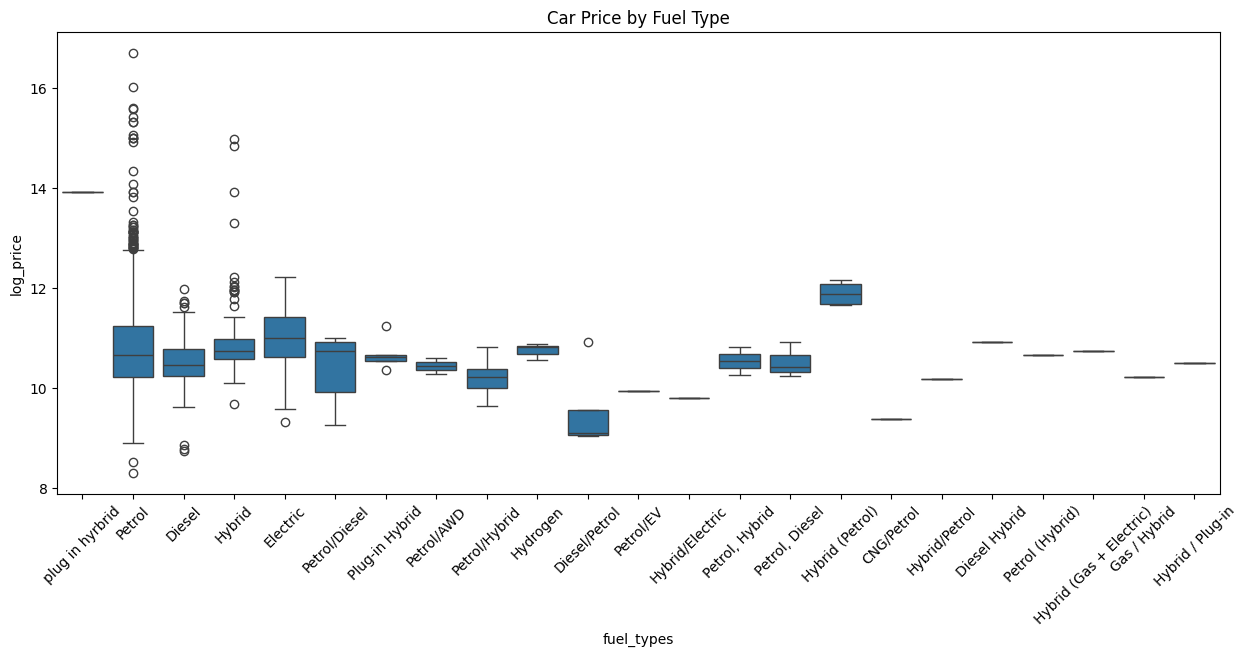

In [10]:
plt.figure(figsize=(15, 6))

sns.boxplot(
    data=df,
    x="fuel_types",
    y="log_price"
)

plt.xticks(rotation=45)
plt.title("Car Price by Fuel Type")

plt.show()

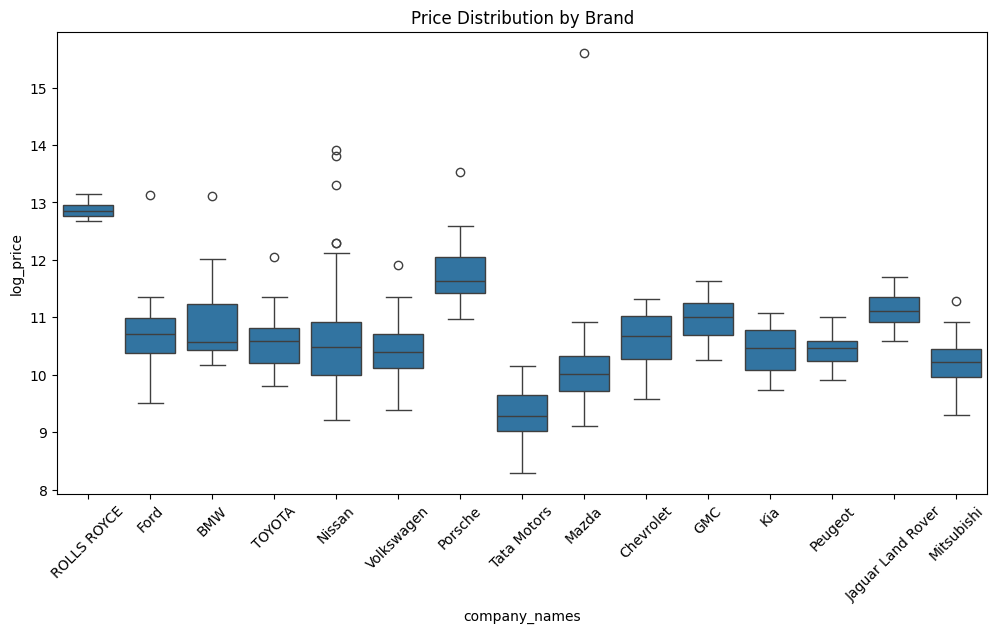

In [11]:
df["company_names"].value_counts().head(15)
top_brands = df["company_names"].value_counts().head(15).index

brand_df = df[df["company_names"].isin(top_brands)]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=brand_df,
    x="company_names",
    y="log_price"
)

plt.xticks(rotation=45)
plt.title("Price Distribution by Brand")

plt.show()

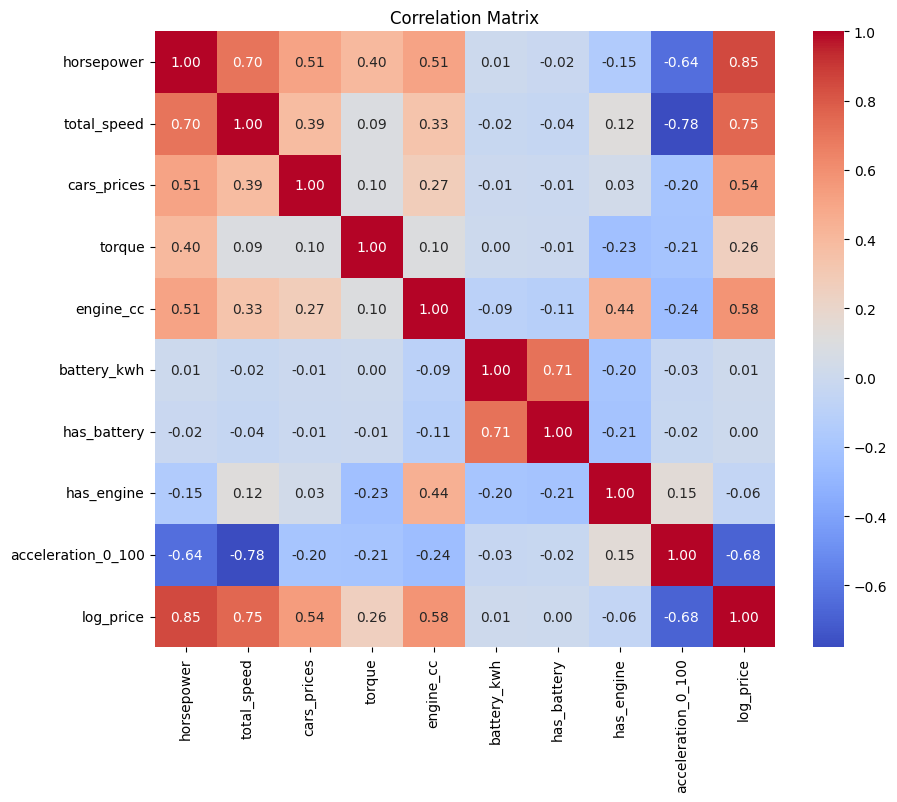

In [12]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

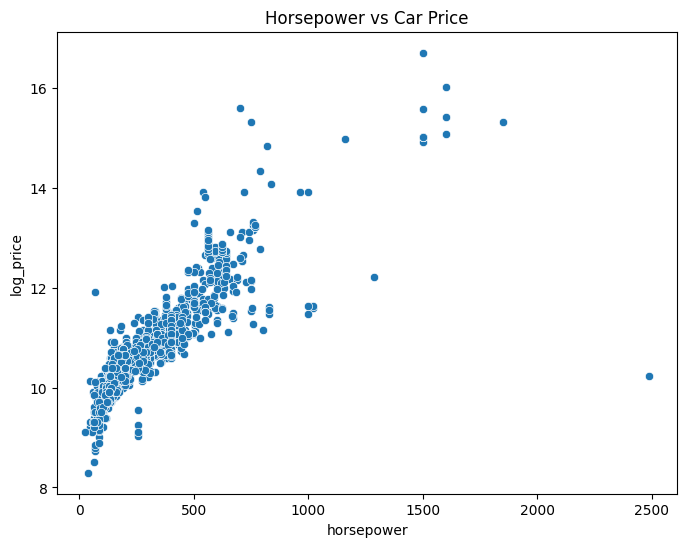

In [13]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="horsepower",
    y="log_price"
)

plt.title("Horsepower vs Car Price")

plt.show()

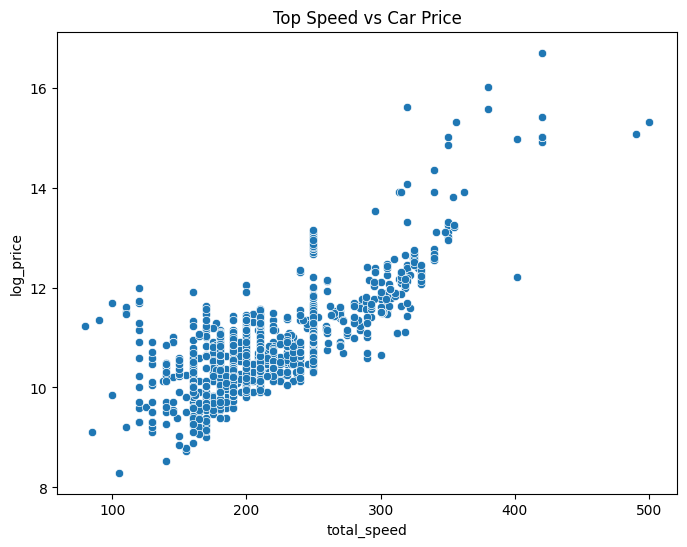

In [14]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="total_speed",
    y="log_price"
)

plt.title("Top Speed vs Car Price")

plt.show()

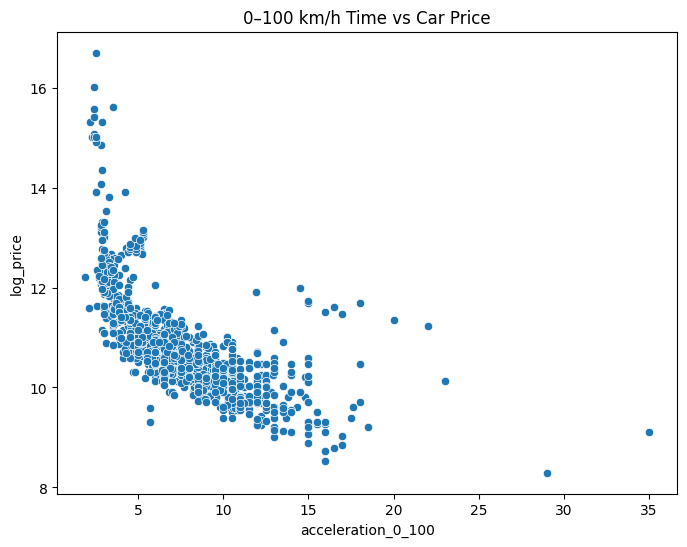

In [15]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="acceleration_0_100",
    y="log_price"
)

plt.title("0–100 km/h Time vs Car Price")

plt.show()

In [16]:
df["log_price"] = np.log1p(df["cars_prices"])
df["performance_score"] = (
    df["horsepower"].rank(pct=True)
    + df["torque"].rank(pct=True)
    + df["total_speed"].rank(pct=True)
    + (1 - df["acceleration_0_100"].rank(pct=True))
)